In [1]:
import torch

In [2]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt

bias = 0
num_features = 1
X_numpy, y_numpy, coef = make_regression(
    n_samples=5000,
    n_features=num_features,
    n_targets=1,
    noise=5,
    bias=bias,
    coef=True,
    random_state=42
)

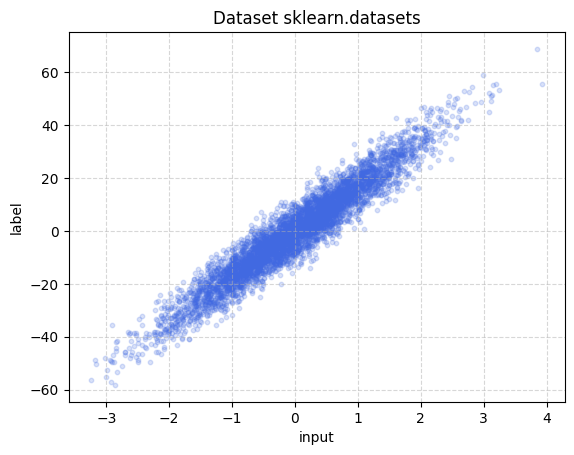

In [7]:

plt.scatter(X_numpy, y_numpy, color='royalblue', alpha=0.2, s=10)

plt.title("Dataset sklearn.datasets")
plt.xlabel("input")
plt.ylabel("label")
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

### Solving the problem with torch way

Suppose we are given $\mathbf{A} \in \mathbb{R}^{m \times n}$ and $\mathbf{b} \in \mathbb{R}^{m \times 1}$ and we want to find the vector $\boldsymbol{x} \in \mathbb{R}^{n \times 1}$ that minimizes $f(\boldsymbol{x})$:

$$
    f(\boldsymbol{x}) = \frac{1}{2} \| \mathbf{A}\boldsymbol{x} -b \|_2^2
$$

In [13]:
X = torch.tensor(X_numpy)
y = torch.tensor(y_numpy)

In [67]:
# function che mi permette di andare a minimizzare f(x)

def torch_minimize_loss(X, y, eps, delta):

    """
    X: matrice delle feature
    y: vettore target
    eps: learning rate
    delta: criterio d'arresto

    Minimizza f(x) = 1/2 * ||Xw - y||^2 usando la discesa del gradiente e autograd.
    """

    # inizializzazione dei pesi w che ci permetteranno di calcolare il gradiente
    w = torch.rand(X.shape[1], dtype=torch.float64, requires_grad=True)

    grad_norm = float('inf') # Inizializziamo con un valore alto

    while grad_norm > delta:
        # Calcolo della previsione e dell'errore (Forward pass)
        loss = 0.5 * torch.norm(X @ w - y)**2

        # 2. Calcolo automatico delle derivate (Backward pass)
        loss.backward()

        grad_norm = torch.norm(w.grad).item()

        # 3. Aggiornamento dei pesi
        with torch.no_grad():
            # Usiamo sub_ (sottrazione in-place) per non creare un nuovo tensore
            w.sub_(eps * w.grad)

            # Azzeriamo il gradiente per l'iterazione successiva
            w.grad.zero_()

    return w.detach().numpy()

wopt = torch_minimize_loss(X,y,1E-6,1E-6)

/tmp/ipykernel_2218/396991765.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  yy = xx @ w


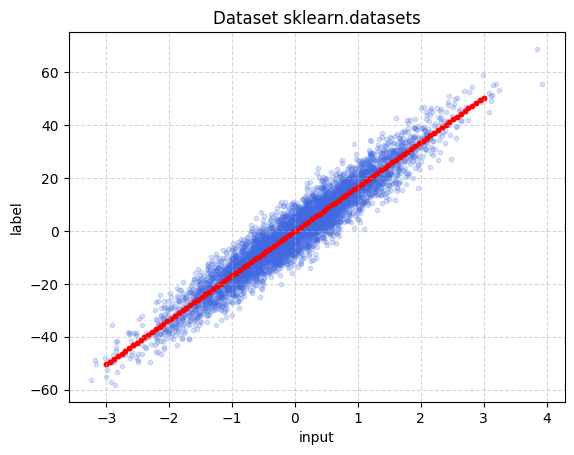

In [22]:
def plot_model(X,y,w):
    xx = torch.linspace(-3, 3, 100, dtype=torch.float64)
    xx = xx.reshape(100,1)
    yy = xx @ w
    plt.scatter(X_numpy, y_numpy, color='royalblue', alpha=0.2, s=10)
    plt.scatter(xx, yy, color='red', s=10)

    plt.title("Dataset sklearn.datasets")
    plt.xlabel("input")
    plt.ylabel("label")
    plt.grid(True, linestyle='--', alpha=0.5)

plot_model(X,y,wopt)

### Exercise: Housing Prices

In [63]:
import pandas as pd
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("yasserh/housing-prices-dataset")
file_path = os.path.join(path, "Housing.csv")

df = pd.read_csv(file_path)

print(df.iloc[0])

Using Colab cache for faster access to the 'housing-prices-dataset' dataset.
price                13300000
area                     7420
bedrooms                    4
bathrooms                   2
stories                     3
mainroad                  yes
guestroom                  no
basement                   no
hotwaterheating            no
airconditioning           yes
parking                     2
prefarea                  yes
furnishingstatus    furnished
Name: 0, dtype: object


#### Least Squares works with number no with character.
1. we have to transform the word *"yes"* and *"no"* in *1* and *0*
2. we have to apply One-Hot Encoding to the "furnishingstatus" column to create dummy variables, dropping the first category to avoid the dummy variable trap.

In [64]:
yes_no_columns = ['mainroad', 'guestroom', 'basement',
                  'hotwaterheating', 'airconditioning', 'prefarea']
df[yes_no_columns] = df[yes_no_columns].replace({'yes': 1, 'no': 0})

# dtype=int transform i True/False generated in 1/0
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True, dtype=int)

print(df.head())

      price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  13300000  7420         4          2        3         1          0   
1  12250000  8960         4          4        4         1          0   
2  12250000  9960         3          2        2         1          0   
3  12215000  7500         4          2        2         1          0   
4  11410000  7420         4          1        2         1          1   

   basement  hotwaterheating  airconditioning  parking  prefarea  \
0         0                0                1        2         1   
1         0                0                1        3         0   
2         1                0                0        2         1   
3         1                0                1        3         1   
4         1                0                1        2         0   

   furnishingstatus_semi-furnished  furnishingstatus_unfurnished  
0                                0                             0  
1                       

/tmp/ipykernel_2218/1619843477.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[yes_no_columns] = df[yes_no_columns].replace({'yes': 1, 'no': 0})


In [65]:
print(df.columns)
print(df['furnishingstatus_unfurnished'][0])
print(df['furnishingstatus_semi-furnished'][0])

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus_semi-furnished',
       'furnishingstatus_unfurnished'],
      dtype='object')
0
0


In [68]:
import torch
import pandas as pd
from sklearn.preprocessing import StandardScaler

X_pandas = df.drop('price', axis=1).values
y_pandas = df['price'].values

# 1. Standardizzazione delle feature (FONDAMENTALE per la discesa del gradiente)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pandas)

# 2. Conversione in Tensori PyTorch
X_tensor = torch.tensor(X_scaled, dtype=torch.float64)
y_tensor = torch.tensor(y_pandas, dtype=torch.float64)

# 3. Aggiunta della colonna di 1 per il Bias (Intercetta)
# Andiamo a creare un vettore colonna di 1 e lo concateniamo a X. Come prima teoria prof
ones = torch.ones(X_tensor.shape[0], 1, dtype=torch.float64)
X_tensor_with_bias = torch.cat((X_tensor, ones), dim=1)


# FARE ATTENZIONE: con i dati scalati, un eps di 1E-6 potrebbe essere un po' piccolo,
# se ci mette troppo tempo ad arrivare a delta cambiamolo (es. 1e-3 o 1e-4)
wopt = torch_minimize_loss(X_tensor_with_bias, y_tensor, 1E-3, 1E-3)

print("Pesi ottimali trovati:", wopt)

Pesi ottimali trovati: [ 529330.60363723   84642.78885404  495817.70908561  390748.26567412
  146735.42974471  114950.32935795  167040.77163724  178965.10323916
  401991.91011662  238532.39119868  276197.74367252  -22847.00683524
 -192857.24250445 4766729.24770642]


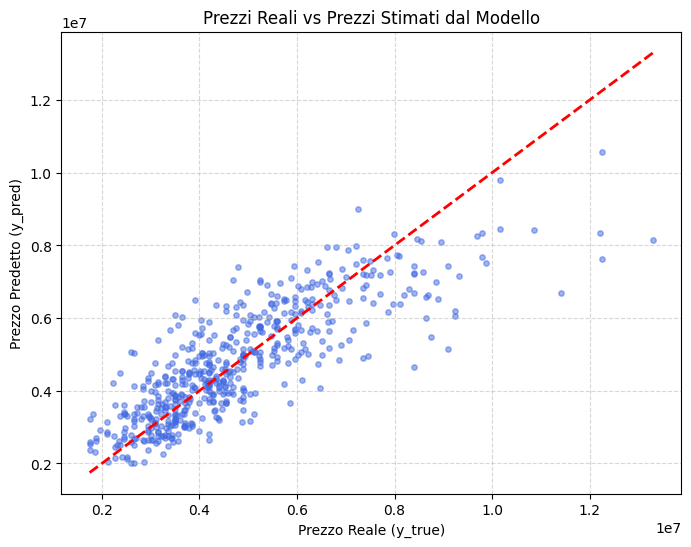

13300000.0, 8133305.30653112


In [74]:
import matplotlib.pyplot as plt
import numpy as np

def plot_true_vs_predicted(X_tensor, y_tensor, w_numpy):
    # Convertiamo i tensori in numpy per comodità
    X_np = X_tensor.numpy()
    y_true = y_tensor.numpy()

    # Calcoliamo le previsioni per tutte le case del dataset
    y_pred = X_np @ w_numpy

    plt.figure(figsize=(8, 6))

    # Disegniamo i punti: Reale vs Predetto
    plt.scatter(y_true, y_pred, color='royalblue', alpha=0.5, s=15)

    # Tracciamo la retta ideale (y = x)
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)

    plt.title("Prezzi Reali vs Prezzi Stimati dal Modello")
    plt.xlabel("Prezzo Reale (y_true)")
    plt.ylabel("Prezzo Predetto (y_pred)")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()
    print(f"{y_true[0]}, {y_pred[0]}")

plot_true_vs_predicted(X_tensor_with_bias, y_tensor, wopt)